# Compare accumulated heat and summer length vs mean temps to establish non-linearity

In [104]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
import pwlf #piecewise linear fits

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

## Load summer stats

In [105]:
ds = xr.open_dataset('../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_stats.nc')
ds

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

In [106]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"

In [120]:
# can be land and inland small water
ds_land = ds.where((ds.lsm > 0.5) & (ds.Coastal == False))
ds_coast = ds.where((ds.lsm > 0.5) & (ds.Coastal))
ds_ocean = ds.where(ds.lsm <= 0.5)

## Plot Mean Heat over time Land vs Ocean

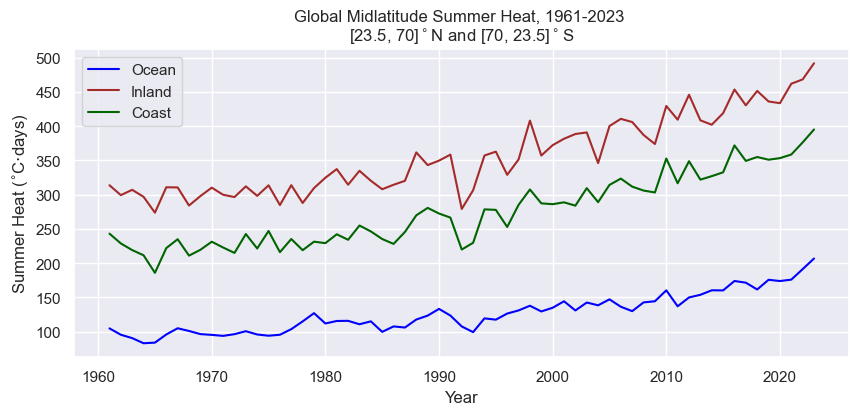

CPU times: user 778 ms, sys: 190 ms, total: 968 ms
Wall time: 971 ms


In [126]:
%%time
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_heat = ds_land.SummerHeat.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_coast_heat = ds_coast.SummerHeat.where(((ds_coast.lat >= 23.5) & (ds_coast.lat <= 70)) | 
                                         ((ds_coast.lat <= -23.5) & (ds_coast.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_heat = ds_ocean.SummerHeat.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_heat.time.dt.year, wavg_midlat_ocean_heat, label="Ocean", color='blue')
plt.plot(wavg_midlat_land_heat.time.dt.year, wavg_midlat_land_heat, label="Inland", color='brown')
plt.plot(wavg_midlat_coast_heat.time.dt.year, wavg_midlat_coast_heat, label="Coast", color='darkgreen')
plt.xlabel("Year")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("Global Midlatitude Summer Heat, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

## Plot Mean T over time Land vs Ocean

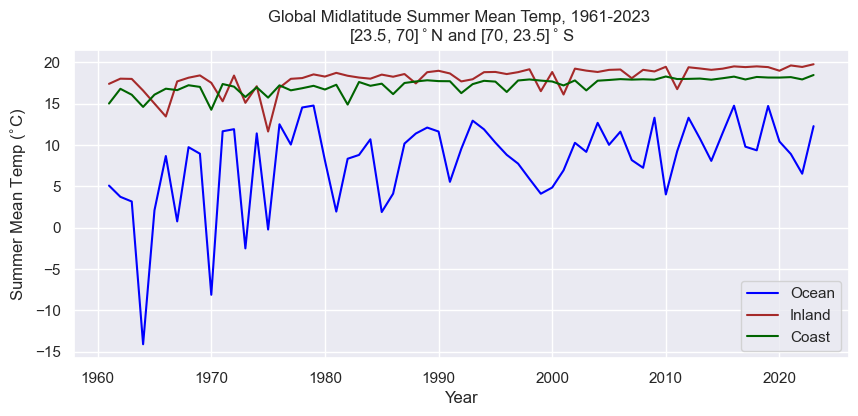

In [124]:
# convert from K to C
KtoC = -273.15

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_meantemp = ds_land.SummerMeanT.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon']) + KtoC
wavg_midlat_ocean_meantemp = ds_ocean.SummerMeanT.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon']) + KtoC
wavg_midlat_coast_meantemp = ds_coast.SummerMeanT.where(((ds_coast.lat >= 23.5) & (ds_coast.lat <= 70)) | 
                                         ((ds_coast.lat <= -23.5) & (ds_coast.lat >= -70))).weighted(weights).mean(dim=['lat','lon']) + KtoC



plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_meantemp.time.dt.year, wavg_midlat_ocean_meantemp, label="Ocean", color='blue')
plt.plot(wavg_midlat_land_meantemp.time.dt.year, wavg_midlat_land_meantemp, label="Inland", color='brown')
plt.plot(wavg_midlat_coast_meantemp.time.dt.year, wavg_midlat_coast_meantemp, label="Coast", color='darkgreen')
plt.xlabel("Year")
plt.ylabel("Summer Mean Temp ($^{\circ}$C)")
plt.title("Global Midlatitude Summer Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

In [45]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20

sns.set_theme(style="darkgrid")

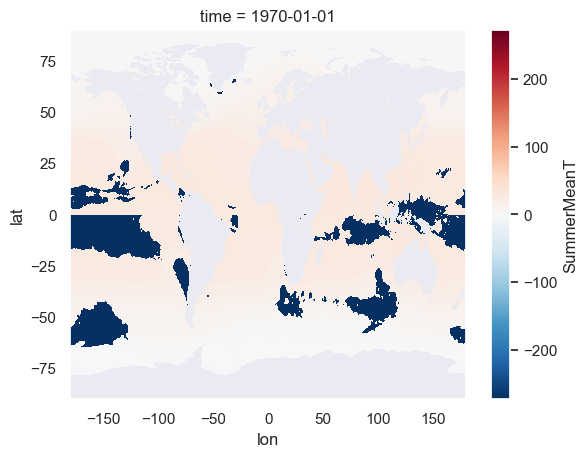

In [241]:
(ds_ocean.SummerMeanT.sel(time="1970")+KtoC).plot()

## Now Mean Heat vs Mean T

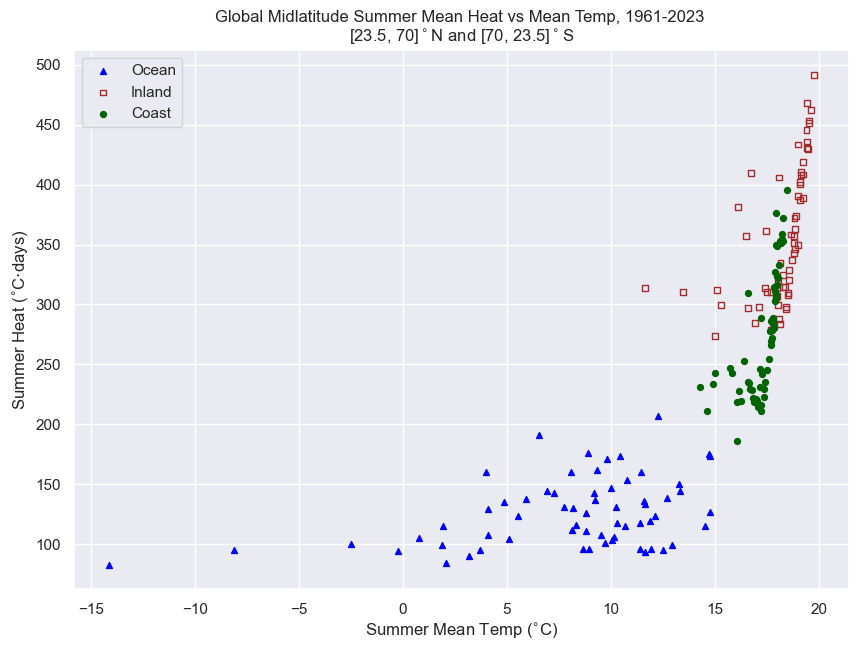

CPU times: user 248 ms, sys: 147 ms, total: 395 ms
Wall time: 936 ms


In [237]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp, y=wavg_midlat_ocean_heat, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp, y=wavg_midlat_land_heat, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp, y=wavg_midlat_coast_heat, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("Global Midlatitude Summer Mean Heat vs Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.savefig("./Plots/MeanHeat_vs_MeanTemp_1961-2023.pdf",bbox_inches='tight')
plt.show()


#### spitballing some curves

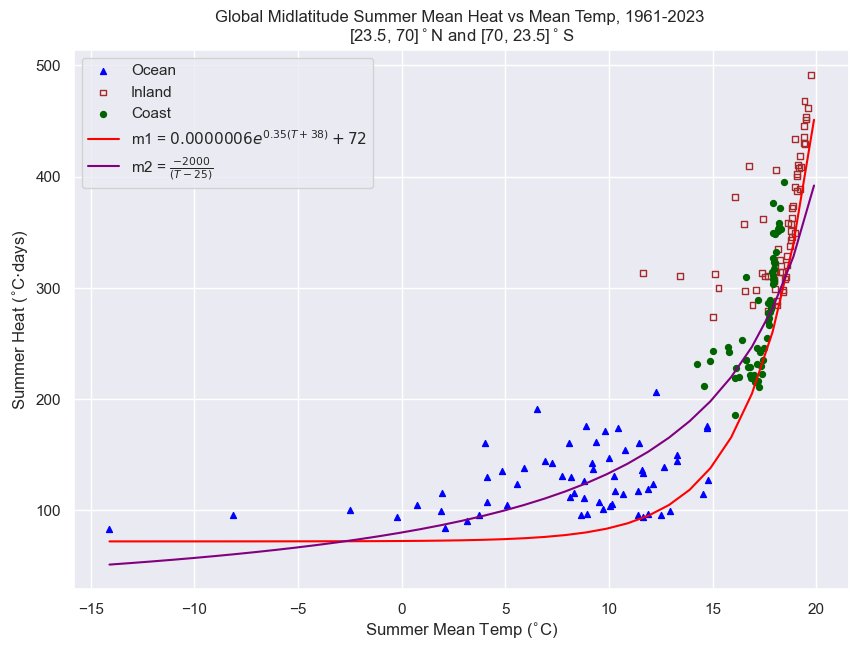

CPU times: user 117 ms, sys: 12.9 ms, total: 130 ms
Wall time: 130 ms


In [231]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

a = 0.0000006
b = 0.35
c = 38
D = 72
xrange = np.arange(min(wavg_midlat_ocean_meantemp.values),max(wavg_midlat_land_meantemp.values)+1,1)

model1 = a*np.exp(b*(xrange + c)) + D

A = -2000
B = -25
model2 = A/(xrange + B)

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp, y=wavg_midlat_ocean_heat, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp, y=wavg_midlat_land_heat, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp, y=wavg_midlat_coast_heat, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xrange, model1, c="red", label="m1 = $0.0000006e^{0.35(T+38)}+72$")
plt.plot(xrange, model2, c="purple", label="m2 = $\\frac{-2000}{(T-25)}$ ")
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("Global Midlatitude Summer Mean Heat vs Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()


## Analysis Period Only

In [128]:
wavg_midlat_land_meantemp_an = wavg_midlat_land_meantemp.sel(time=slice('1990','2023'))
wavg_midlat_ocean_meantemp_an = wavg_midlat_ocean_meantemp.sel(time=slice('1990','2023'))
wavg_midlat_coast_meantemp_an = wavg_midlat_coast_meantemp.sel(time=slice('1990','2023'))

wavg_midlat_land_heat_an = wavg_midlat_land_heat.sel(time=slice('1990','2023'))
wavg_midlat_ocean_heat_an = wavg_midlat_ocean_heat.sel(time=slice('1990','2023'))
wavg_midlat_coast_heat_an = wavg_midlat_coast_heat.sel(time=slice('1990','2023'))


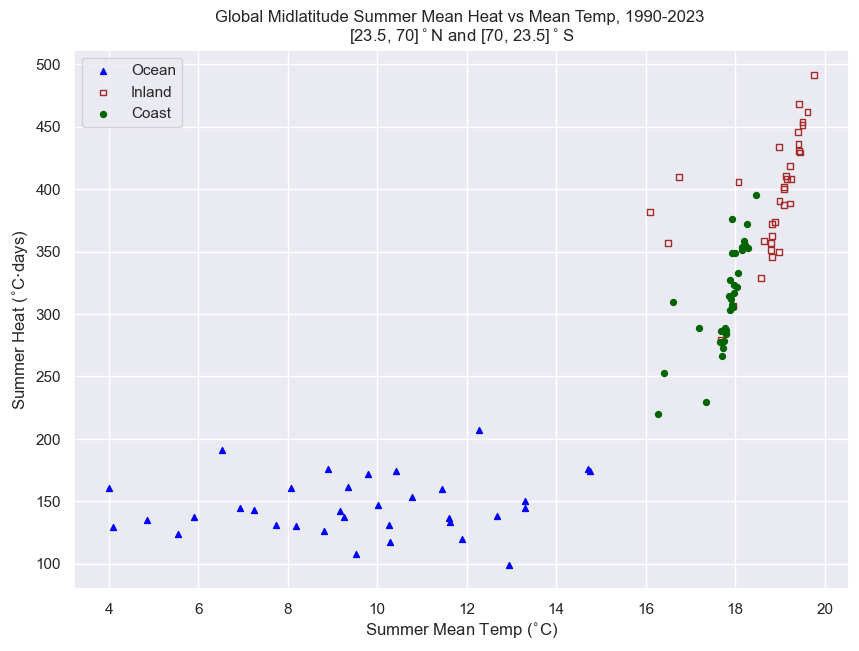

CPU times: user 110 ms, sys: 20.6 ms, total: 131 ms
Wall time: 161 ms


In [129]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp_an, y=wavg_midlat_ocean_heat_an, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp_an, y=wavg_midlat_land_heat_an, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp_an, y=wavg_midlat_coast_heat_an, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("Global Midlatitude Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()


### Split into Inland/Coast/Ocean

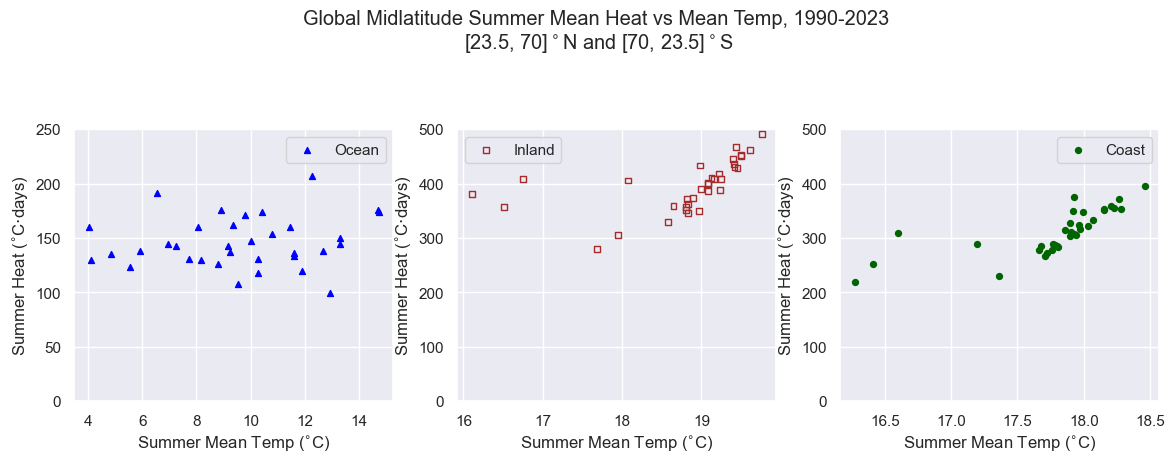

CPU times: user 118 ms, sys: 26.1 ms, total: 144 ms
Wall time: 170 ms


In [131]:
%%time

# takes XXX min

plt.figure(figsize=(14,12))
plt.subplot(331)
plt.scatter(x=wavg_midlat_ocean_meantemp_an, y=wavg_midlat_ocean_heat_an, s=s, marker=o_m, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,250)
plt.legend()
plt.subplot(332)
plt.scatter(x=wavg_midlat_land_meantemp_an, y=wavg_midlat_land_heat_an, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,500)
plt.legend()
plt.subplot(333)
plt.scatter(x=wavg_midlat_coast_meantemp_an, y=wavg_midlat_coast_heat_an, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(0,500)
plt.suptitle("Global Midlatitude Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

### Then split by hemisphere

In [28]:
%%time

# takes 36 sec

# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

# datasets of weighted averages for the midlatitudes

nh_ocean_full = ds.where((ds.lsm <= 0.5) & 
                              ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_full = ds.where((ds.lsm <= 0.5) & 
                              ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_an = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_an = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_land_full = ds.where((ds.lsm > 0.5) &  (ds.Coastal == False) & 
                             ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_full = ds.where((ds.Coastal)  & 
                              ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_full = ds.where((ds.lsm > 0.5)  & (ds.Coastal == False) & 
                             ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_full = ds.where((ds.Coastal)  & 
                              ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & 
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_an = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & 
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & 
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_an = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & 
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])





CPU times: user 25.4 s, sys: 26.4 s, total: 51.8 s
Wall time: 57 s


#### NH 1990-2023

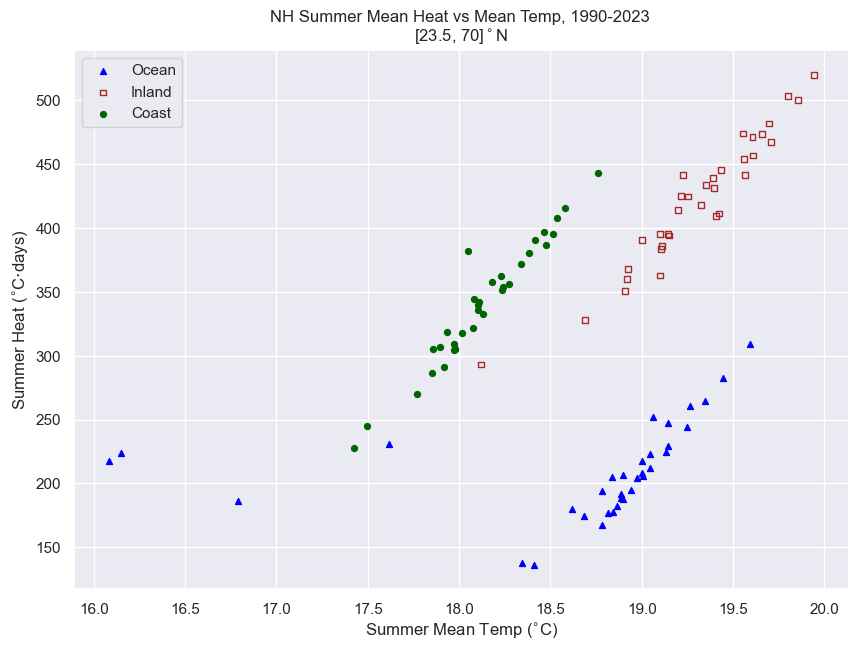

CPU times: user 105 ms, sys: 17.7 ms, total: 123 ms
Wall time: 148 ms


In [133]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=nh_ocean_an.SummerMeanT+KtoC, y=nh_ocean_an.SummerHeat, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=nh_land_an.SummerMeanT+KtoC, y=nh_land_an.SummerHeat, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=nh_coast_an.SummerMeanT+KtoC, y=nh_coast_an.SummerHeat, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("NH Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.legend()
plt.show()


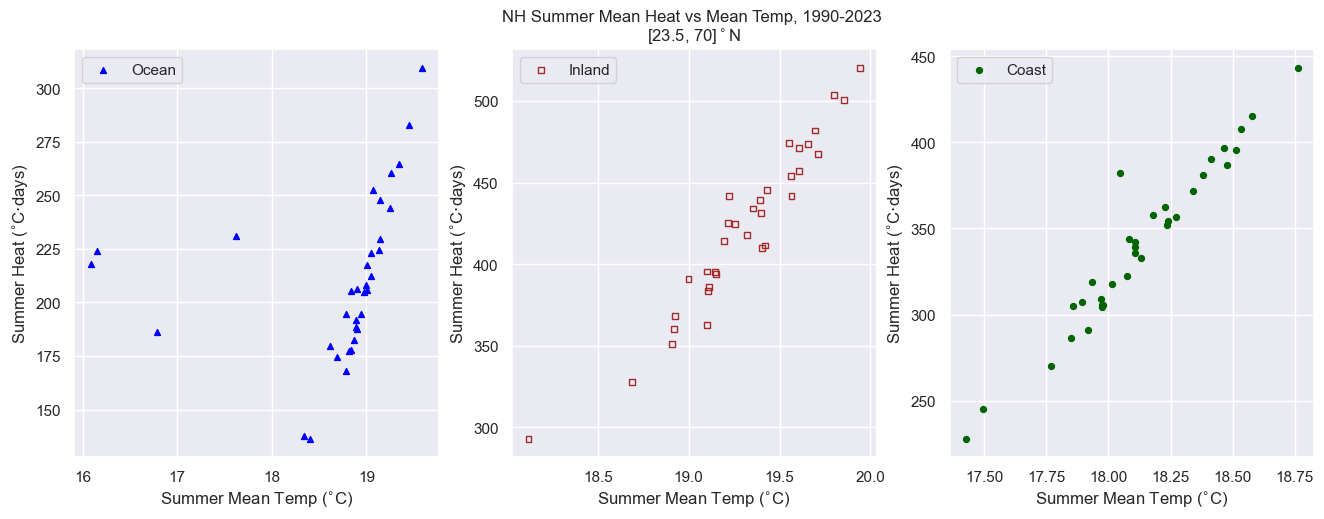

CPU times: user 147 ms, sys: 16.5 ms, total: 163 ms
Wall time: 184 ms


In [132]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)
plt.scatter(x=nh_ocean_an.SummerMeanT+KtoC, y=nh_ocean_an.SummerHeat, s=s, marker=o_m, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)
plt.title("NH Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x=nh_land_an.SummerMeanT+KtoC, y=nh_land_an.SummerHeat, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)
plt.scatter(x=nh_coast_an.SummerMeanT+KtoC, y=nh_coast_an.SummerHeat, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

Ocean RMSE: 45.655 NRMSE: 0.217 and R^2: 0.822
Land RMSE: 54.271 NRMSE: 0.129 and R^2: 0.92
Coast RMSE: 29.135 NRMSE: 0.086 and R^2: 0.938


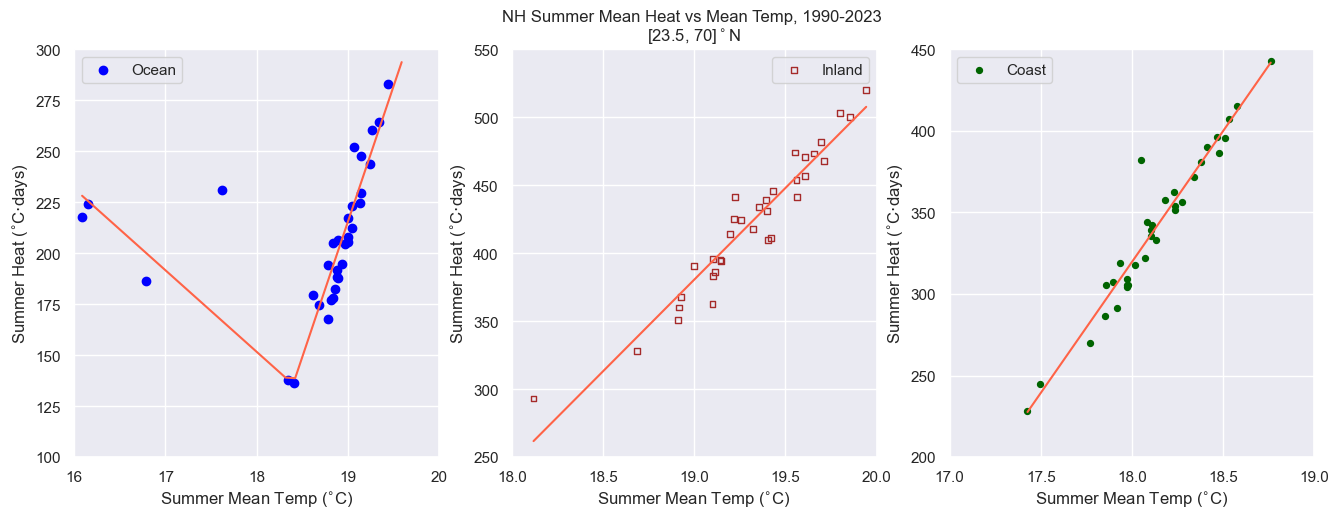

CPU times: user 140 ms, sys: 37.1 ms, total: 177 ms
Wall time: 214 ms


In [134]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (nh_ocean_an.SummerMeanT+KtoC).values
y = nh_ocean_an.SummerHeat.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# your desired line segment end locations
x0 = np.array([min(x), 18.4, max(x)])

# fit the data with a break as above
res = my_pwlf.fit_with_breaks(x0)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(100,300)
plt.xlim(16,20)
plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (nh_land_an.SummerMeanT+KtoC).values
y = nh_land_an.SummerHeat.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Land RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("NH Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(250,550)
plt.xlim(18,20)
plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (nh_coast_an.SummerMeanT+KtoC).values
y = nh_coast_an.SummerHeat.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.ylim(200,450)
plt.xlim(17,19)
plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### SQRT(Heat) vs T

Ocean RMSE: 1.623 NRMSE: 0.112 and R^2: 0.825
Inland RMSE: 1.36 NRMSE: 0.066 and R^2: 0.928
Coast RMSE: 0.816 NRMSE: 0.044 and R^2: 0.937


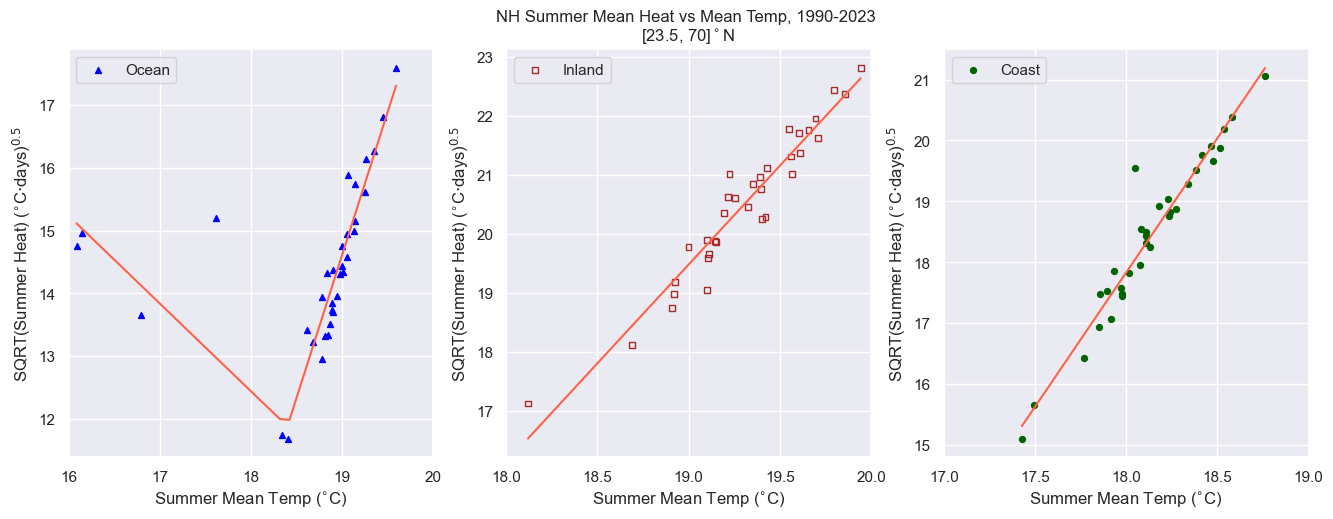

CPU times: user 134 ms, sys: 6.43 ms, total: 140 ms
Wall time: 140 ms


In [135]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (nh_ocean_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_ocean_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# your desired line segment end locations
x0 = np.array([min(x), 18.4, max(x)])

# fit the data with a break as above
res = my_pwlf.fit_with_breaks(x0)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Heat) ($^{\circ}$C$\cdot$days)$^{0.5}$")
#plt.ylim(100,300)
plt.xlim(16,20)
plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (nh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_land_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("NH Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Heat) ($^{\circ}$C$\cdot$days)$^{0.5}$")
#plt.ylim(250,550)
plt.xlim(18,20)
plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (nh_coast_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_coast_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Heat) ($^{\circ}$C$\cdot$days)$^{0.5}$")
#plt.ylim(200,450)
plt.xlim(17,19)
plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### LOG(Heat) vs T

Ocean RMSE: 0.233 NRMSE: 0.044 and R^2: 0.823
Inland RMSE: 1.36 NRMSE: 0.066 and R^2: 0.928
Coast RMSE: 0.093 NRMSE: 0.016 and R^2: 0.933


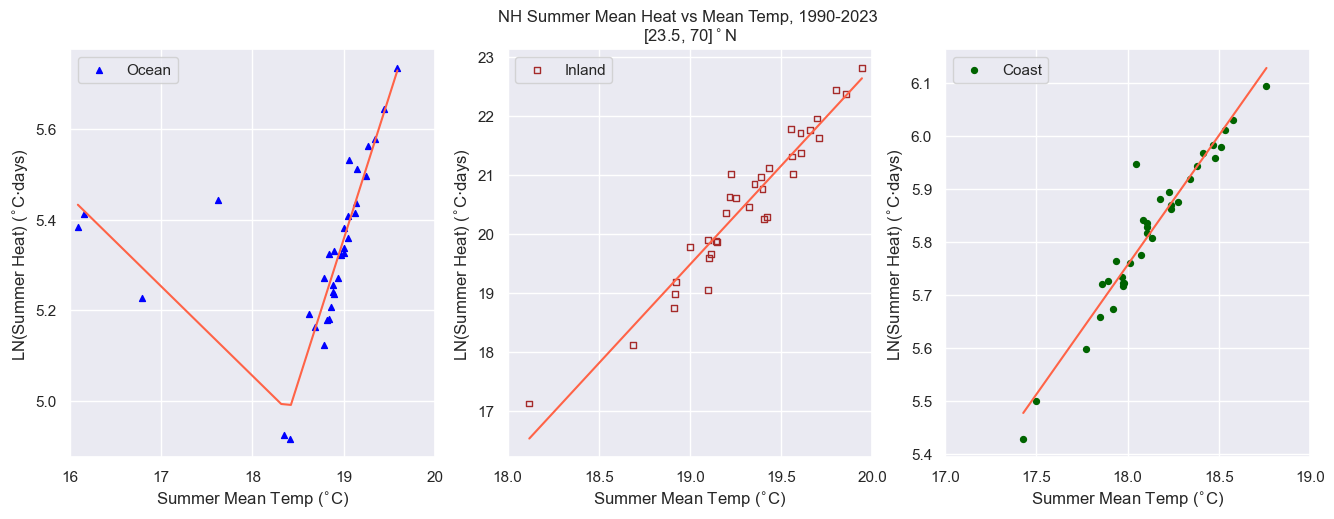

CPU times: user 122 ms, sys: 23.8 ms, total: 146 ms
Wall time: 150 ms


In [137]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (nh_ocean_an.SummerMeanT+KtoC).values
y = np.log(nh_ocean_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# your desired line segment end locations
x0 = np.array([min(x), 18.4, max(x)])

# fit the data with a break as above
res = my_pwlf.fit_with_breaks(x0)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Heat) ($^{\circ}$C$\cdot$days)")
#plt.ylim(100,300)
plt.xlim(16,20)
plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (nh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_land_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("NH Summer Mean Heat vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Heat) ($^{\circ}$C$\cdot$days)")
#plt.ylim(250,550)
plt.xlim(18,20)
plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (nh_coast_an.SummerMeanT+KtoC).values
y = np.log(nh_coast_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Heat) ($^{\circ}$C$\cdot$days)")
#plt.ylim(200,450)
plt.xlim(17,19)
plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### SH 1990-2023

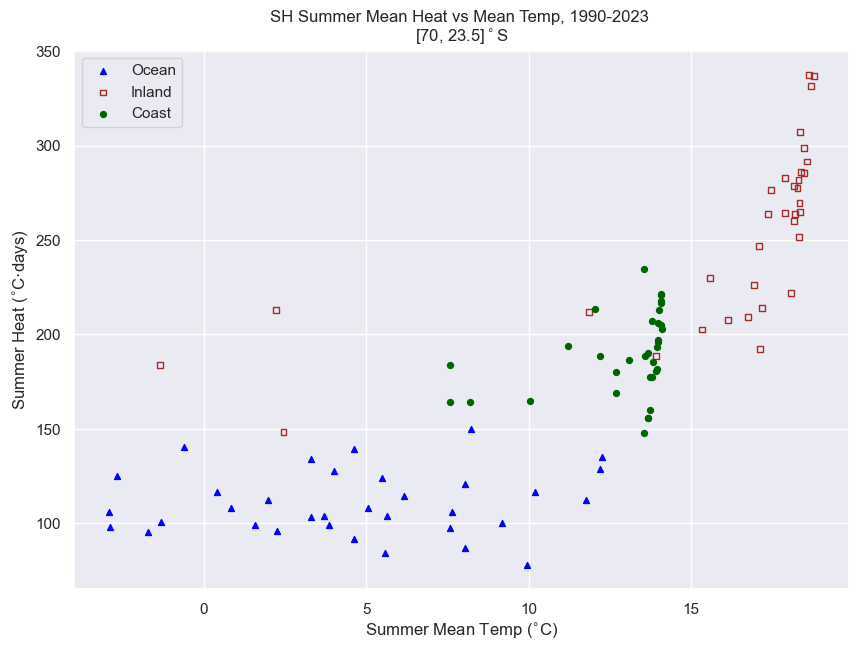

CPU times: user 78.1 ms, sys: 23.8 ms, total: 102 ms
Wall time: 116 ms


In [141]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=sh_ocean_an.SummerMeanT+KtoC, y=sh_ocean_an.SummerHeat, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=sh_land_an.SummerMeanT+KtoC, y=sh_land_an.SummerHeat, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=sh_coast_an.SummerMeanT+KtoC, y=sh_coast_an.SummerHeat, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
plt.title("SH Summer Mean Heat vs Mean Temp, 1990-2023 \n[70, 23.5]$^\circ$S")
plt.legend()
plt.show()


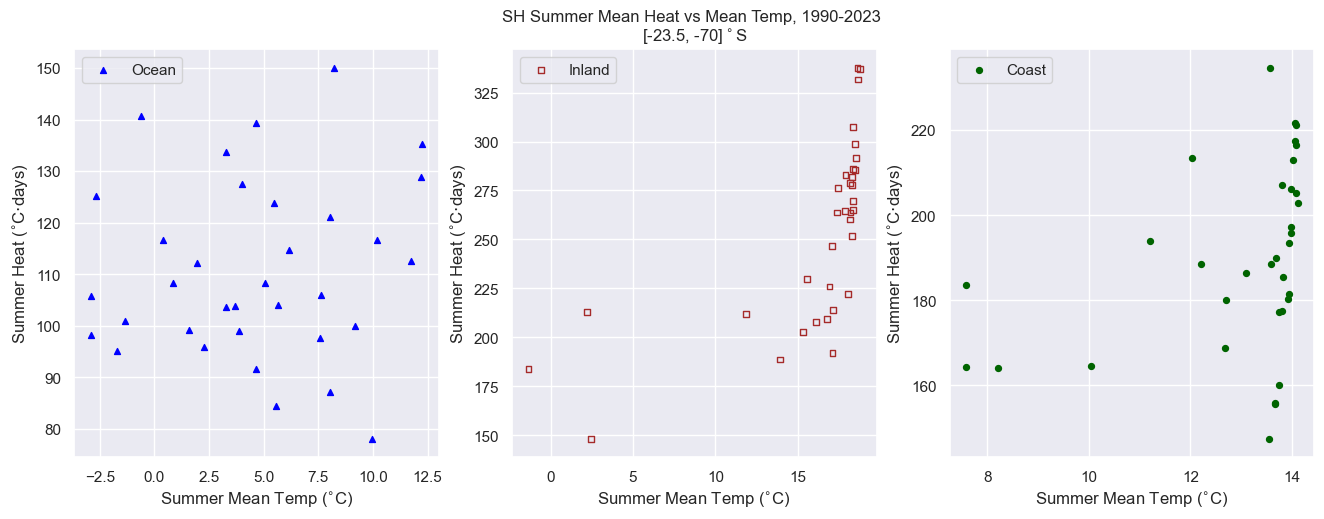

CPU times: user 150 ms, sys: 24.8 ms, total: 175 ms
Wall time: 203 ms


In [142]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)
plt.scatter(x=sh_ocean_an.SummerMeanT+KtoC, y=sh_ocean_an.SummerHeat, s=s, marker=o_m, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)
plt.title("SH Summer Mean Heat vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x=sh_land_an.SummerMeanT+KtoC, y=sh_land_an.SummerHeat, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)
plt.scatter(x=sh_coast_an.SummerMeanT+KtoC, y=sh_coast_an.SummerHeat, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### Linear fit

Ocean RMSE: 15.498 NRMSE: 0.14 and R^2: 0.009
Land RMSE: 64.686 NRMSE: 0.256 and R^2: 0.777
Coast RMSE: 21.941 NRMSE: 0.116 and R^2: 0.392


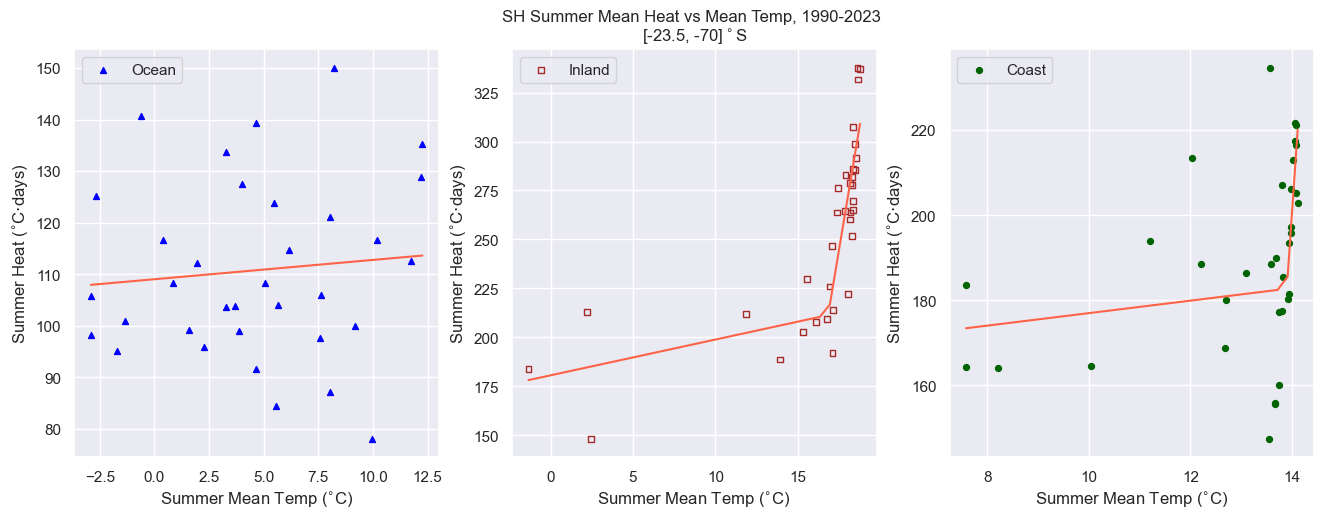

CPU times: user 177 ms, sys: 14.5 ms, total: 192 ms
Wall time: 200 ms


In [140]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (sh_ocean_an.SummerMeanT+KtoC).values
y = sh_ocean_an.SummerHeat.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data with a break as above
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (sh_land_an.SummerMeanT+KtoC).values
y = sh_land_an.SummerHeat.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Land RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("SH Summer Mean Heat vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (sh_coast_an.SummerMeanT+KtoC).values
y = sh_coast_an.SummerHeat.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Heat ($^{\circ}$C$\cdot$days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### SQRT(Heat) vs T

Ocean RMSE: 0.738 NRMSE: 0.07 and R^2: 0.007
Inland RMSE: 2.102 NRMSE: 0.133 and R^2: 0.779
Coast RMSE: 0.8 NRMSE: 0.058 and R^2: 0.388


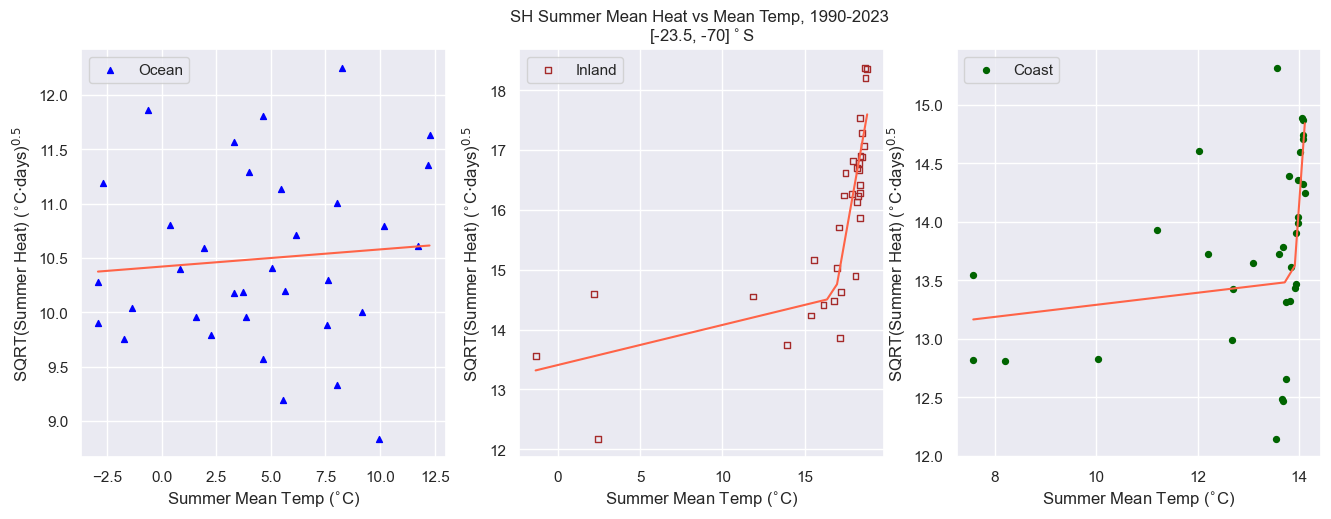

CPU times: user 209 ms, sys: 37.9 ms, total: 247 ms
Wall time: 394 ms


In [143]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (sh_ocean_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_ocean_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data with a break as above
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Heat) ($^{\circ}$C$\cdot$days)$^{0.5}$")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (sh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_land_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("SH Summer Mean Heat vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Heat) ($^{\circ}$C$\cdot$days)$^{0.5}$")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (sh_coast_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_coast_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Heat) ($^{\circ}$C$\cdot$days)$^{0.5}$")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### LOG(Heat) vs T

Ocean RMSE: 0.142 NRMSE: 0.03 and R^2: 0.006
Inland RMSE: 2.102 NRMSE: 0.133 and R^2: 0.779
Coast RMSE: 0.117 NRMSE: 0.022 and R^2: 0.384


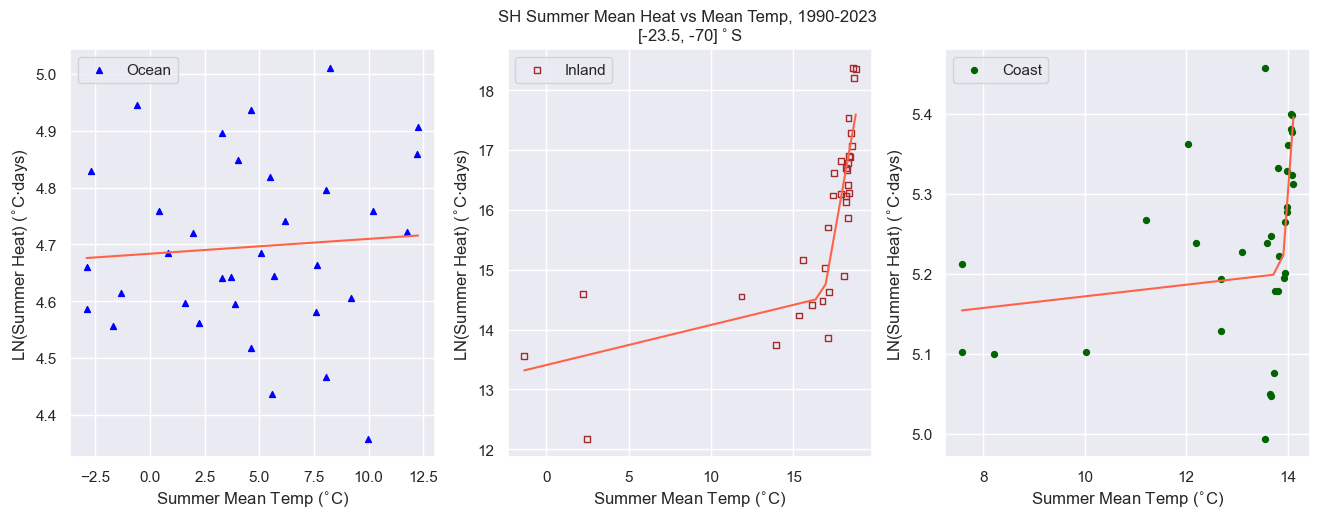

CPU times: user 171 ms, sys: 17 ms, total: 188 ms
Wall time: 184 ms


In [144]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (sh_ocean_an.SummerMeanT+KtoC).values
y = np.log(sh_ocean_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data with a break as above
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Heat) ($^{\circ}$C$\cdot$days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (sh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_land_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("SH Summer Mean Heat vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Heat) ($^{\circ}$C$\cdot$days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (sh_coast_an.SummerMeanT+KtoC).values
y = np.log(sh_coast_an.SummerHeat.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Heat) ($^{\circ}$C$\cdot$days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

## Length

## Plot Mean Length over time Land vs Ocean

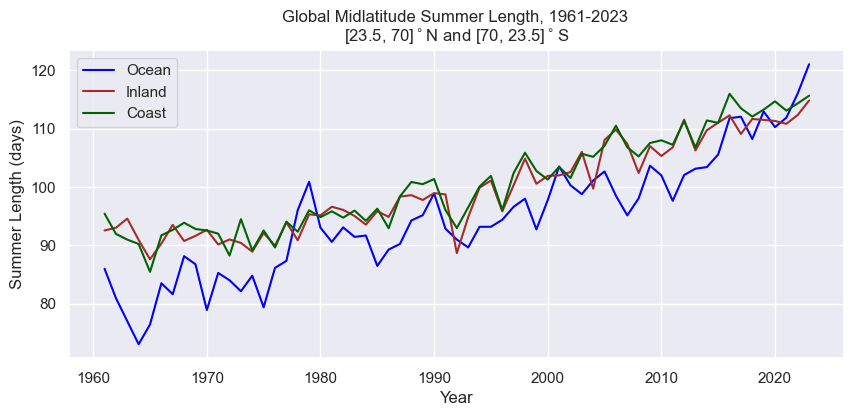

In [145]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_length = ds_land.SummerLength.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_length = ds_ocean.SummerLength.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_coast_length = ds_coast.SummerLength.where(((ds_coast.lat >= 23.5) & (ds_coast.lat <= 70)) | 
                                         ((ds_coast.lat <= -23.5) & (ds_coast.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_length.time.dt.year, wavg_midlat_ocean_length, label="Ocean", color='blue')
plt.plot(wavg_midlat_land_length.time.dt.year, wavg_midlat_land_length, label="Inland", color='brown')
plt.plot(wavg_midlat_coast_length.time.dt.year, wavg_midlat_coast_length, label="Coast", color='darkgreen')
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Length, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

In [45]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20

sns.set_theme(style="darkgrid")

## Now Mean Length vs Mean T

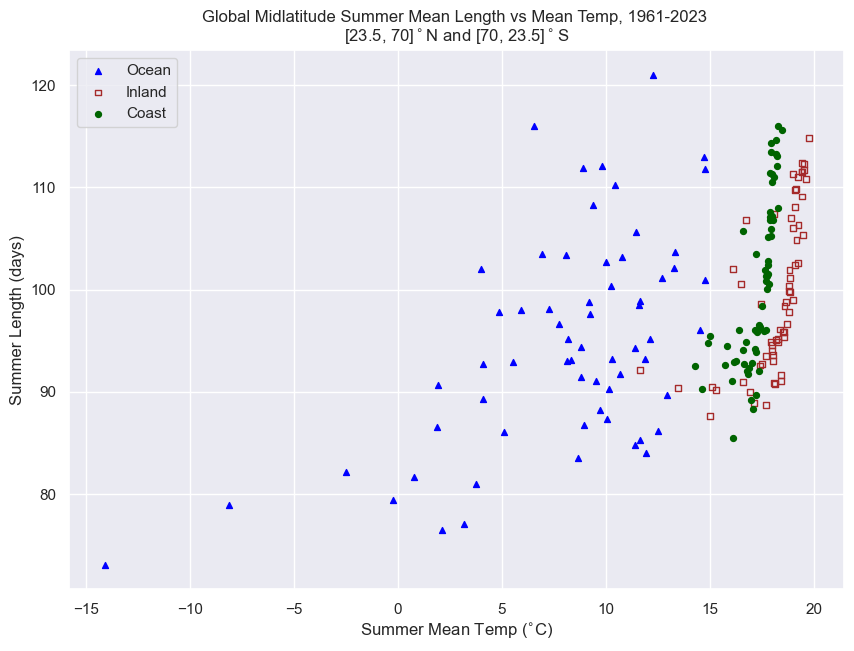

CPU times: user 89.6 ms, sys: 29.7 ms, total: 119 ms
Wall time: 139 ms


In [146]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp, y=wavg_midlat_ocean_length, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp, y=wavg_midlat_land_length, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp, y=wavg_midlat_coast_length, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Mean Length vs Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()


#### spitballing some curves again

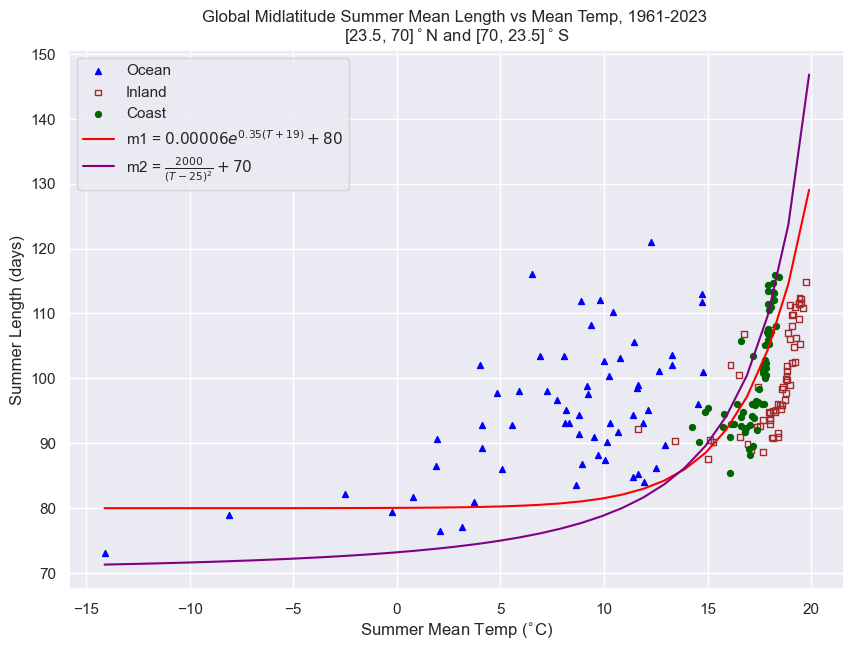

CPU times: user 403 ms, sys: 195 ms, total: 598 ms
Wall time: 769 ms


In [229]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

a = 0.00006
b = 0.35
c = 19
D = 80
xrange = np.arange(min(wavg_midlat_ocean_meantemp.values),max(wavg_midlat_land_meantemp.values)+1,1)

model1 = a*np.exp(b*(xrange + c)) + D

A = 2000
B = -25
G = 70
model2 = A/(xrange + B)**2 + G

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp, y=wavg_midlat_ocean_length, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp, y=wavg_midlat_land_length, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp, y=wavg_midlat_coast_length, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xrange, model1, c="red", label="m1 = $0.00006e^{0.35(T+19)}+80$")
plt.plot(xrange, model2, c="purple", label="m2 = $\\frac{2000}{(T-25)^2} + 70$ ")
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Mean Length vs Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()


## Analysis Period Only

In [147]:


wavg_midlat_land_length_an = wavg_midlat_land_length.sel(time=slice('1990','2023'))
wavg_midlat_ocean_length_an = wavg_midlat_ocean_length.sel(time=slice('1990','2023'))
wavg_midlat_coast_length_an = wavg_midlat_coast_length.sel(time=slice('1990','2023'))


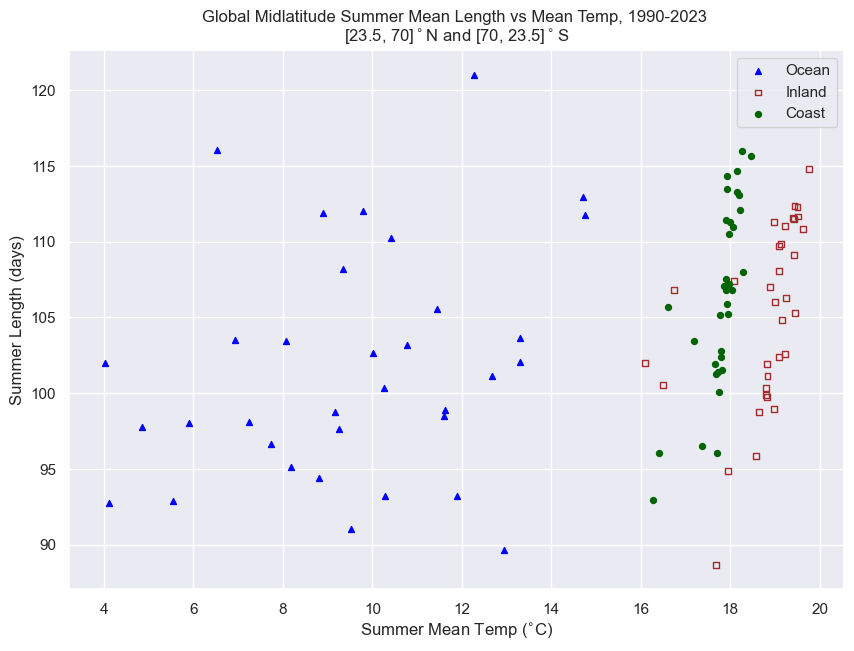

CPU times: user 121 ms, sys: 49.5 ms, total: 171 ms
Wall time: 440 ms


In [148]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp_an, y=wavg_midlat_ocean_length_an, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp_an, y=wavg_midlat_land_length_an, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp_an, y=wavg_midlat_coast_length_an, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Mean Length vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()


### Split into Inland/Coast/Ocean

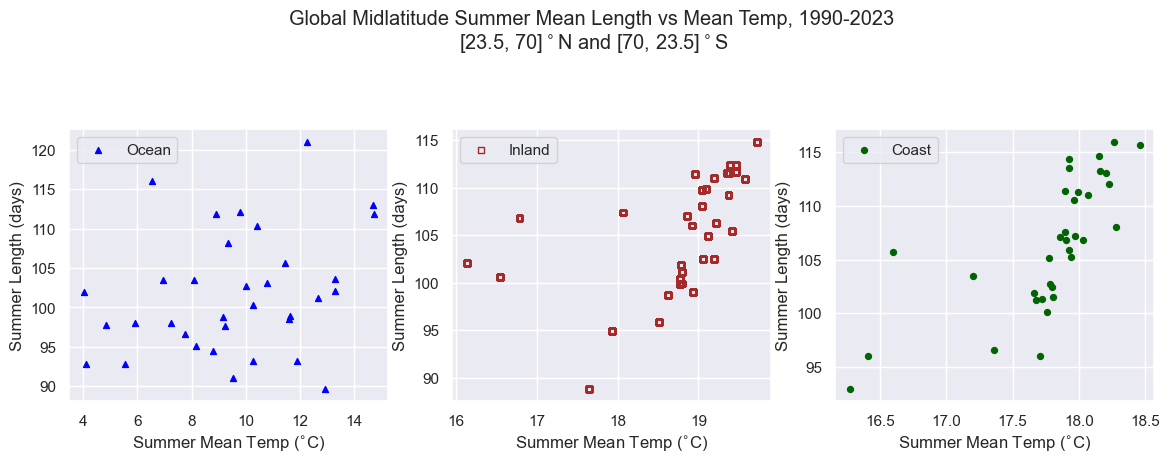

CPU times: user 2min 36s, sys: 18.2 s, total: 2min 54s
Wall time: 3min


In [149]:
%%time

# takes 2.5 min

plt.figure(figsize=(14,12))
plt.subplot(331)
plt.scatter(x=wavg_midlat_ocean_meantemp_an.values, y=wavg_midlat_ocean_length_an.values, s=s, marker=o_m, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(0,250)
plt.legend()
plt.subplot(332)
plt.scatter(x=wavg_midlat_inland_meantemp_an.values, y=wavg_midlat_inland_length_an.values, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(0,500)
plt.legend()
plt.subplot(333)
plt.scatter(x=wavg_midlat_coast_meantemp_an.values, y=wavg_midlat_coast_length_an.values, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(0,500)
plt.suptitle("Global Midlatitude Summer Mean Length vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

### Then split by hemisphere

#### NH 1990-2023

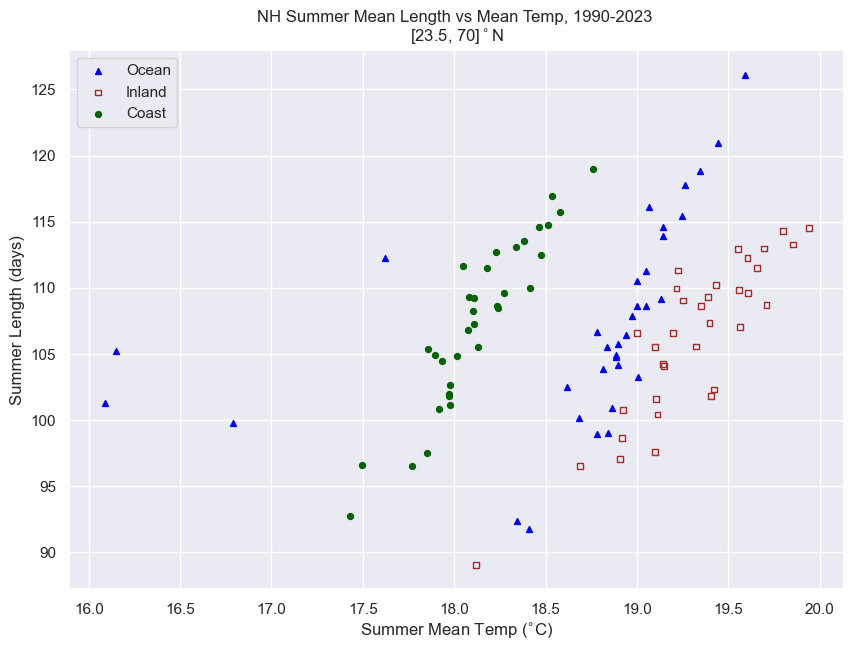

CPU times: user 96.1 ms, sys: 26 ms, total: 122 ms
Wall time: 149 ms


In [151]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=nh_ocean_an.SummerMeanT+KtoC, y=nh_ocean_an.SummerLength, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=nh_land_an.SummerMeanT+KtoC, y=nh_land_an.SummerLength, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=nh_coast_an.SummerMeanT+KtoC, y=nh_coast_an.SummerLength, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
plt.title("NH Summer Mean Length vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.legend()
plt.show()


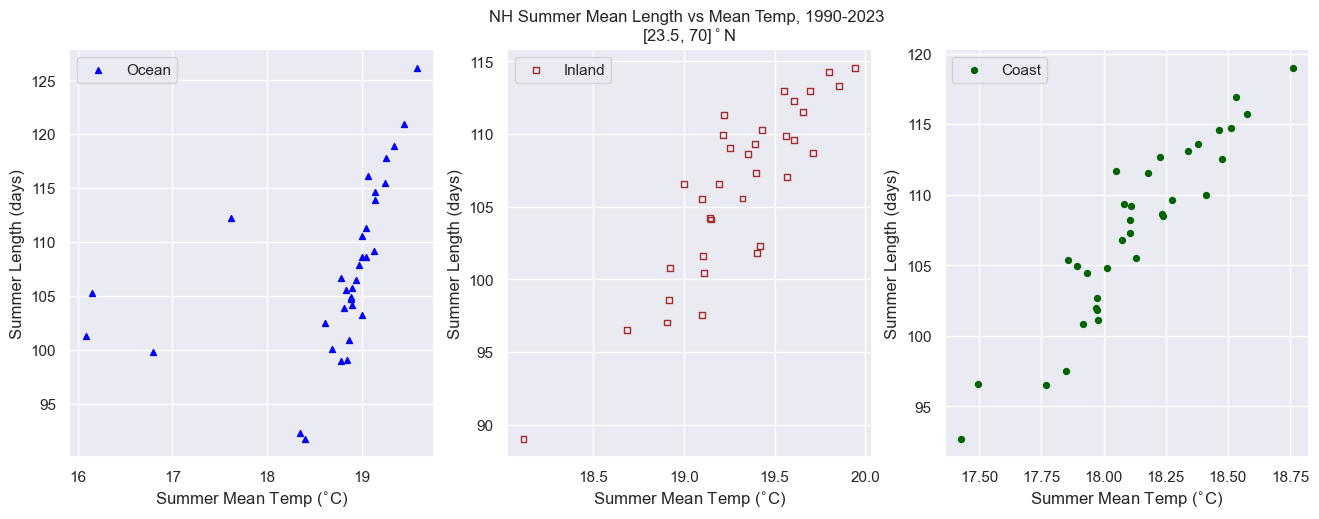

CPU times: user 140 ms, sys: 21.3 ms, total: 161 ms
Wall time: 186 ms


In [150]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)
plt.scatter(x=nh_ocean_an.SummerMeanT+KtoC, y=nh_ocean_an.SummerLength, s=s, marker=o_m, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)
plt.title("NH Summer Mean Length vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x=nh_land_an.SummerMeanT+KtoC, y=nh_land_an.SummerLength, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)
plt.scatter(x=nh_coast_an.SummerMeanT+KtoC, y=nh_coast_an.SummerLength, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

Ocean RMSE: 8.117 NRMSE: 0.076 and R^2: 0.773
Land RMSE: 5.812 NRMSE: 0.055 and R^2: 0.76
Coast RMSE: 3.573 NRMSE: 0.033 and R^2: 0.864


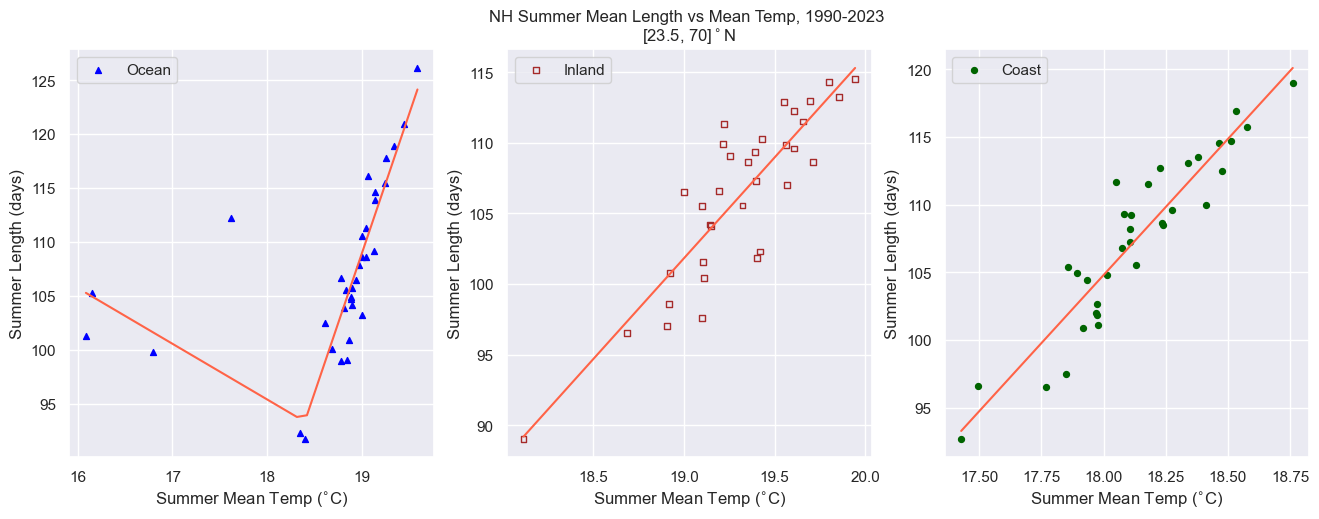

CPU times: user 137 ms, sys: 8.93 ms, total: 146 ms
Wall time: 147 ms


In [153]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (nh_ocean_an.SummerMeanT+KtoC).values
y = nh_ocean_an.SummerLength.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# your desired line segment end locations
x0 = np.array([min(x), 18.4, max(x)])

# fit the data with a break as above
res = my_pwlf.fit_with_breaks(x0)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
# plt.ylim(100,300)
# plt.xlim(16,20)
# plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (nh_land_an.SummerMeanT+KtoC).values
y = nh_land_an.SummerLength.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Land RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("NH Summer Mean Length vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
# plt.ylim(250,550)
# plt.xlim(18,20)
# plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (nh_coast_an.SummerMeanT+KtoC).values
y = nh_coast_an.SummerLength.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
# plt.ylim(200,450)
# plt.xlim(17,19)
# plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### SQRT(Length) vs T

Ocean RMSE: 0.396 NRMSE: 0.038 and R^2: 0.771
Inland RMSE: 0.288 NRMSE: 0.028 and R^2: 0.763
Coast RMSE: 0.175 NRMSE: 0.017 and R^2: 0.862


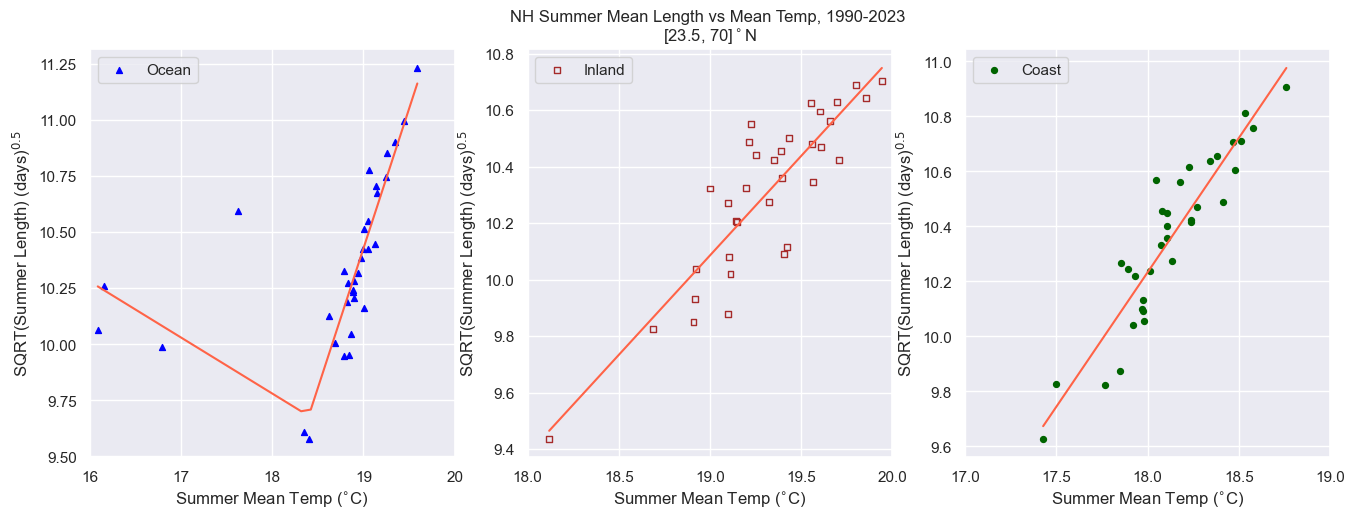

CPU times: user 139 ms, sys: 13 ms, total: 152 ms
Wall time: 152 ms


In [154]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (nh_ocean_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_ocean_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# your desired line segment end locations
x0 = np.array([min(x), 18.4, max(x)])

# fit the data with a break as above
res = my_pwlf.fit_with_breaks(x0)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Length) (days)$^{0.5}$")
#plt.ylim(100,300)
plt.xlim(16,20)
plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (nh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_land_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("NH Summer Mean Length vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Length) (days)$^{0.5}$")
#plt.ylim(250,550)
plt.xlim(18,20)
plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (nh_coast_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_coast_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Length) (days)$^{0.5}$")
#plt.ylim(200,450)
plt.xlim(17,19)
plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### LOG(Length) vs T

Ocean RMSE: 0.077 NRMSE: 0.017 and R^2: 0.769
Inland RMSE: 0.288 NRMSE: 0.028 and R^2: 0.763
Coast RMSE: 0.034 NRMSE: 0.007 and R^2: 0.859


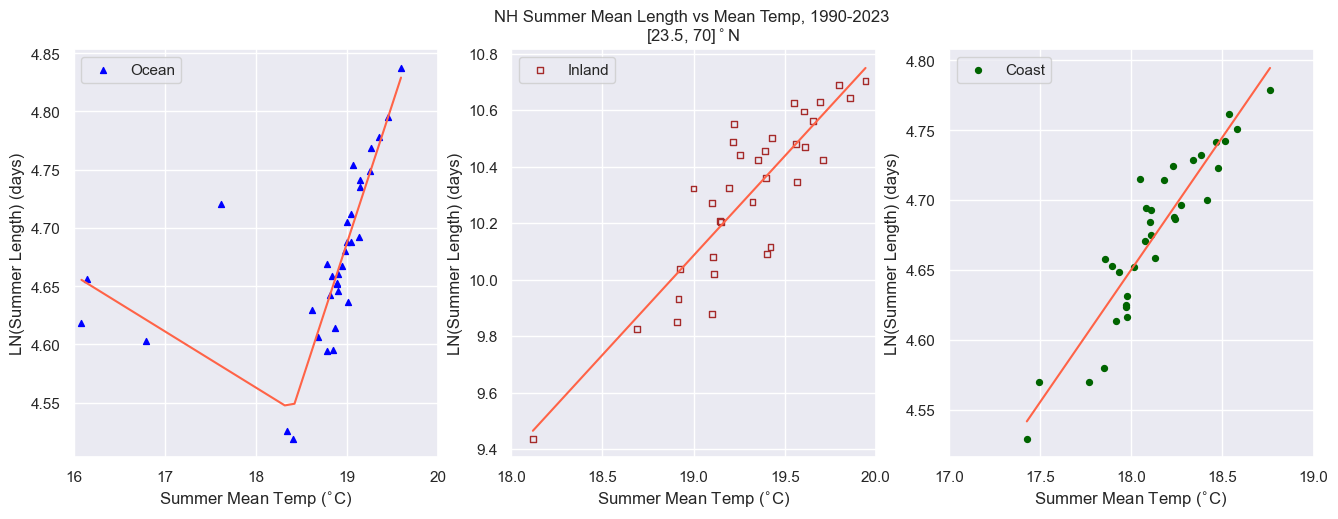

CPU times: user 140 ms, sys: 8.22 ms, total: 148 ms
Wall time: 148 ms


In [156]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (nh_ocean_an.SummerMeanT+KtoC).values
y = np.log(nh_ocean_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# your desired line segment end locations
x0 = np.array([min(x), 18.4, max(x)])

# fit the data with a break as above
res = my_pwlf.fit_with_breaks(x0)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Length) (days)")
#plt.ylim(100,300)
plt.xlim(16,20)
plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (nh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(nh_land_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("NH Summer Mean Length vs Mean Temp, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Length) (days)")
#plt.ylim(250,550)
plt.xlim(18,20)
plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (nh_coast_an.SummerMeanT+KtoC).values
y = np.log(nh_coast_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Length) (days)")
#plt.ylim(200,450)
plt.xlim(17,19)
plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### SH 1990-2023

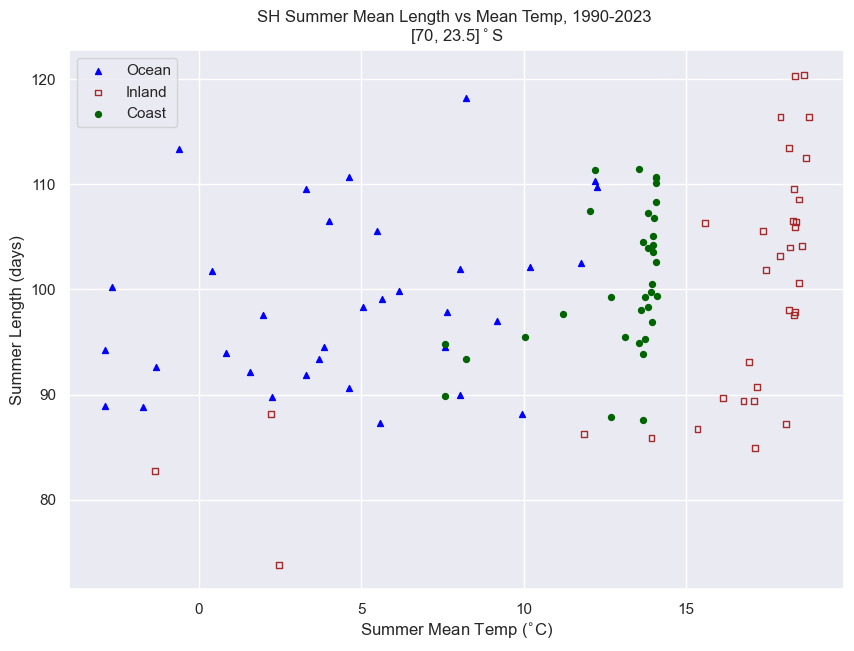

CPU times: user 88.9 ms, sys: 13.4 ms, total: 102 ms
Wall time: 118 ms


In [158]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=sh_ocean_an.SummerMeanT+KtoC, y=sh_ocean_an.SummerLength, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=sh_land_an.SummerMeanT+KtoC, y=sh_land_an.SummerLength, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=sh_coast_an.SummerMeanT+KtoC, y=sh_coast_an.SummerLength, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
plt.title("SH Summer Mean Length vs Mean Temp, 1990-2023 \n[70, 23.5]$^\circ$S")
plt.legend()
plt.show()


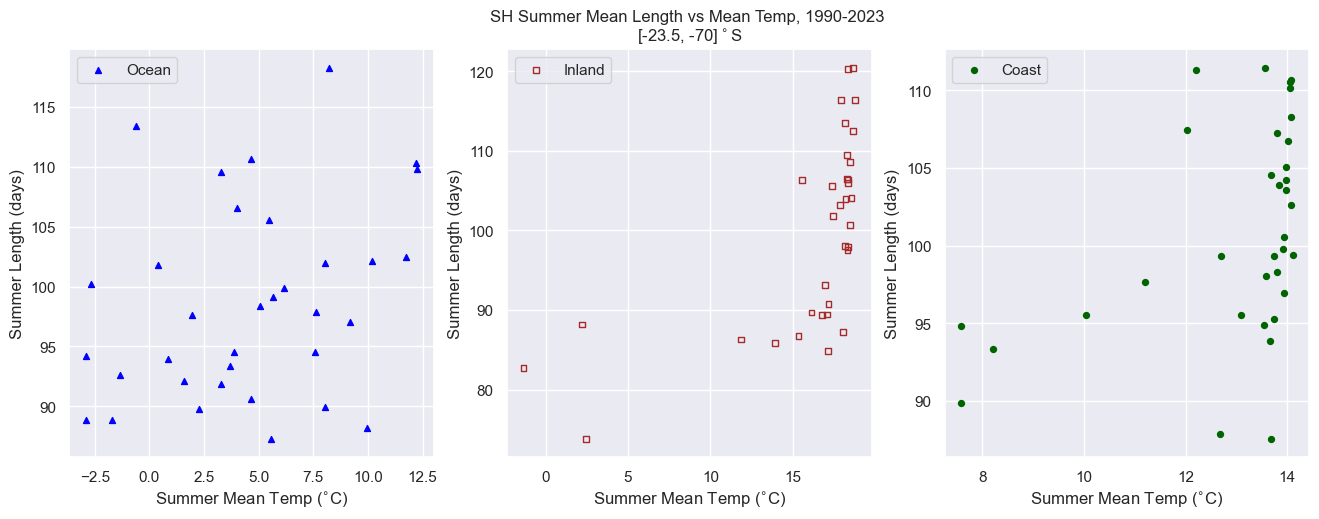

CPU times: user 341 ms, sys: 145 ms, total: 486 ms
Wall time: 529 ms


In [159]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)
plt.scatter(x=sh_ocean_an.SummerMeanT+KtoC, y=sh_ocean_an.SummerLength, s=s, marker=o_m, label="Ocean", color='blue')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)
plt.title("SH Summer Mean Length vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x=sh_land_an.SummerMeanT+KtoC, y=sh_land_an.SummerLength, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)
plt.scatter(x=sh_coast_an.SummerMeanT+KtoC, y=sh_coast_an.SummerLength, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### Linear fit

Ocean RMSE: 5.998 NRMSE: 0.061 and R^2: 0.091
Land RMSE: 15.676 NRMSE: 0.158 and R^2: 0.618
Coast RMSE: 6.681 NRMSE: 0.066 and R^2: 0.308


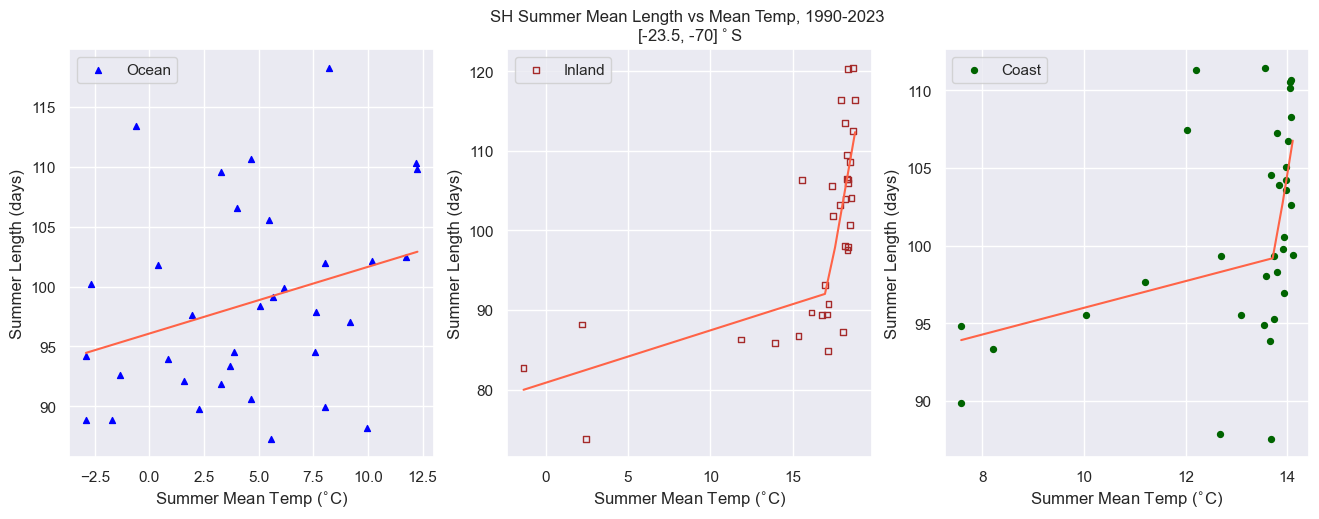

CPU times: user 177 ms, sys: 16.3 ms, total: 193 ms
Wall time: 188 ms


In [160]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (sh_ocean_an.SummerMeanT+KtoC).values
y = sh_ocean_an.SummerLength.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data with a break as above
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (sh_land_an.SummerMeanT+KtoC).values
y = sh_land_an.SummerLength.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Land RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("SH Summer Mean Length vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (sh_coast_an.SummerMeanT+KtoC).values
y = sh_coast_an.SummerLength.values
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Length (days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### SQRT(Length) vs T

Ocean RMSE: 0.299 NRMSE: 0.03 and R^2: 0.091
Inland RMSE: 0.797 NRMSE: 0.08 and R^2: 0.626
Coast RMSE: 0.334 NRMSE: 0.033 and R^2: 0.311


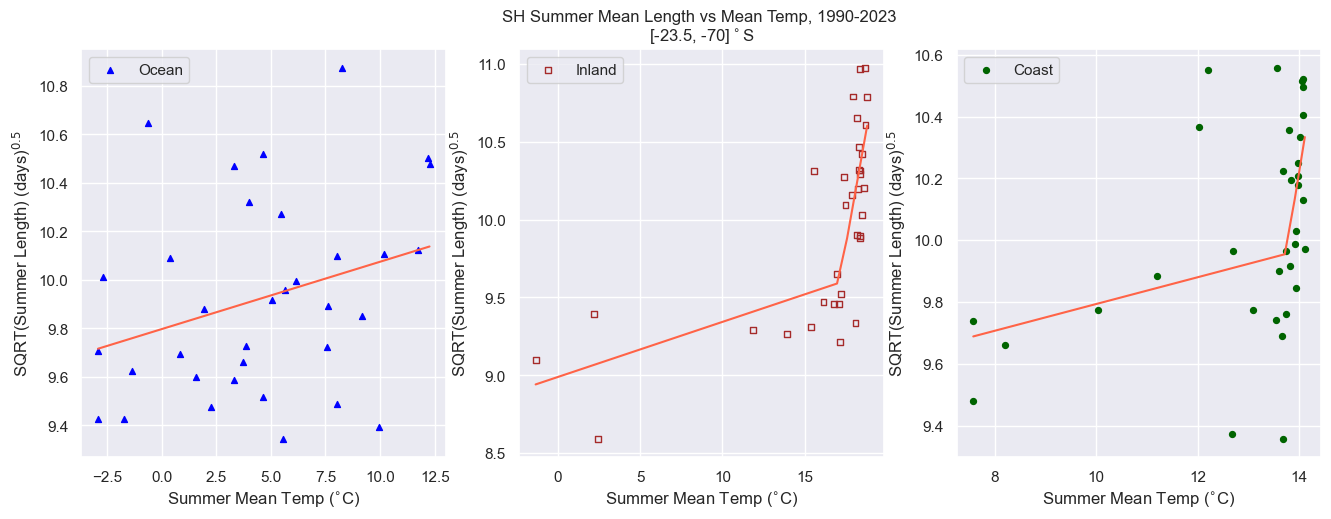

CPU times: user 189 ms, sys: 18.8 ms, total: 208 ms
Wall time: 206 ms


In [161]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (sh_ocean_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_ocean_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data with a break as above
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Length) (days)$^{0.5}$")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (sh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_land_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("SH Summer Mean Length vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Length) (days)$^{0.5}$")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (sh_coast_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_coast_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("SQRT(Summer Length) (days)$^{0.5}$")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

#### LOG(Length) vs T

Ocean RMSE: 0.06 NRMSE: 0.013 and R^2: 0.092
Inland RMSE: 0.797 NRMSE: 0.08 and R^2: 0.626
Coast RMSE: 0.067 NRMSE: 0.014 and R^2: 0.313


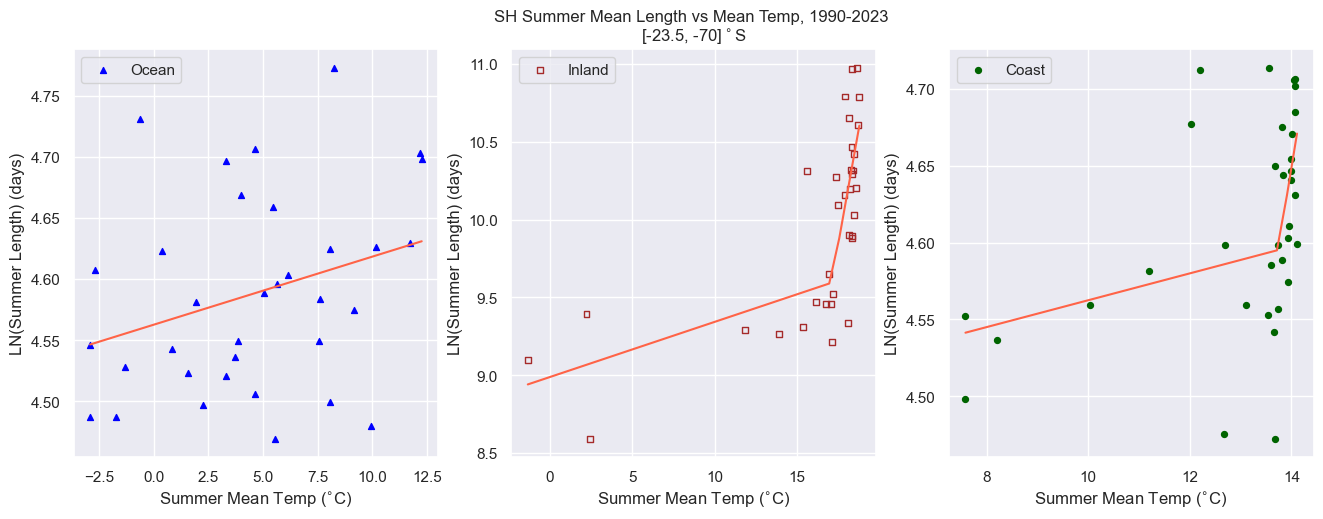

CPU times: user 170 ms, sys: 27.8 ms, total: 198 ms
Wall time: 192 ms


In [162]:
%%time

# takes a minute

plt.figure(figsize=(16,18))
plt.subplot(331)

# Ocean
x = (sh_ocean_an.SummerMeanT+KtoC).values
y = np.log(sh_ocean_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data with a break as above
res = my_pwlf.fit(1)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Ocean RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=o_m, label="Ocean", color='blue')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Length) (days)")
#plt.ylim(100,300)
#plt.xlim(16,20)
#plt.xticks([16,17,18,19,20])
plt.legend()
plt.subplot(332)

# Inland
x = (sh_land_an.SummerMeanT+KtoC).values
y = np.sqrt(sh_land_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Inland RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.title("SH Summer Mean Length vs Mean Temp, 1990-2023 \n[-23.5, -70]$^\circ$S")
plt.scatter(x, y, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Length) (days)")
#plt.ylim(250,550)
#plt.xlim(18,20)
#plt.xticks([18,18.5,19,19.5,20])
plt.legend()
plt.subplot(333)

# Coast
x = (sh_coast_an.SummerMeanT+KtoC).values
y = np.log(sh_coast_an.SummerLength.values)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
# fit the data for specified line segments 
res = my_pwlf.fit(2)
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
RMSE = np.sqrt(MSR)
NRMSE = RMSE/(np.mean(y))
print("Coast RMSE: "+str(np.round(RMSE,3))+" NRMSE: "+str(np.round(NRMSE,3))+" and R^2: "+str(np.round(my_pwlf.r_squared(),3)))

plt.scatter(x, y, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.plot(xHat, yHat, '-', c='tomato')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("LN(Summer Length) (days)")
#plt.ylim(200,450)
#plt.xlim(17,19)
#plt.xticks([17,17.5,18,18.5,19])
plt.legend()
plt.show()

## Onset

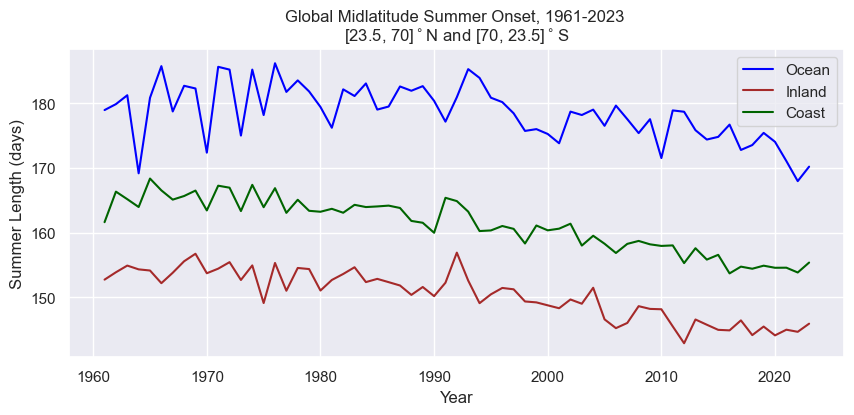

In [233]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_onset = ds_land.SummerStart.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_onset = ds_ocean.SummerStart.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_coast_onset = ds_coast.SummerStart.where(((ds_coast.lat >= 23.5) & (ds_coast.lat <= 70)) | 
                                         ((ds_coast.lat <= -23.5) & (ds_coast.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_onset.time.dt.year, wavg_midlat_ocean_onset, label="Ocean", color='blue')
plt.plot(wavg_midlat_land_onset.time.dt.year, wavg_midlat_land_onset, label="Inland", color='brown')
plt.plot(wavg_midlat_coast_onset.time.dt.year, wavg_midlat_coast_onset, label="Coast", color='darkgreen')
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Onset, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

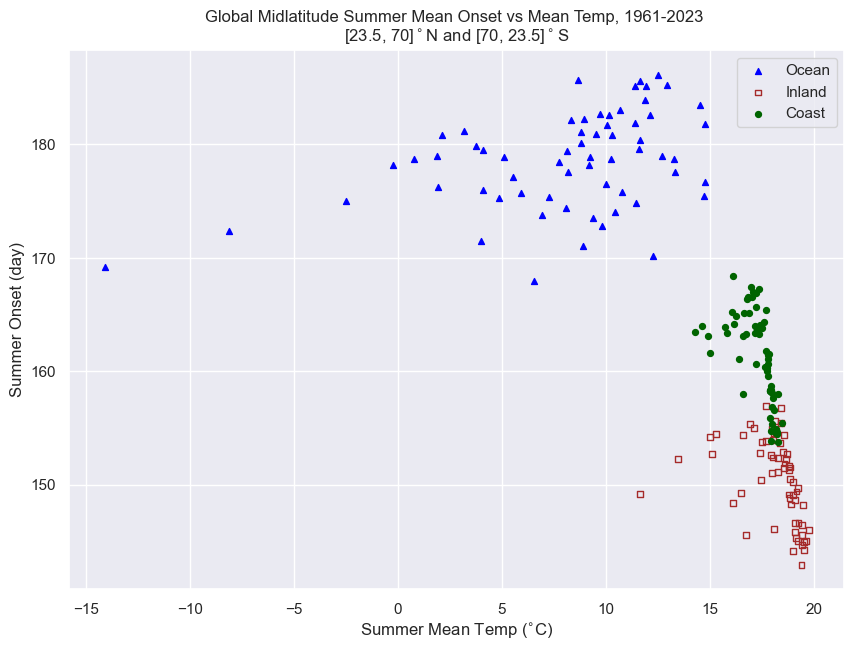

CPU times: user 87.1 ms, sys: 31.6 ms, total: 119 ms
Wall time: 149 ms


In [234]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp, y=wavg_midlat_ocean_onset, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp, y=wavg_midlat_land_onset, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp, y=wavg_midlat_coast_onset, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Onset (day)")
plt.title("Global Midlatitude Summer Mean Onset vs Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()


## Withdrawal

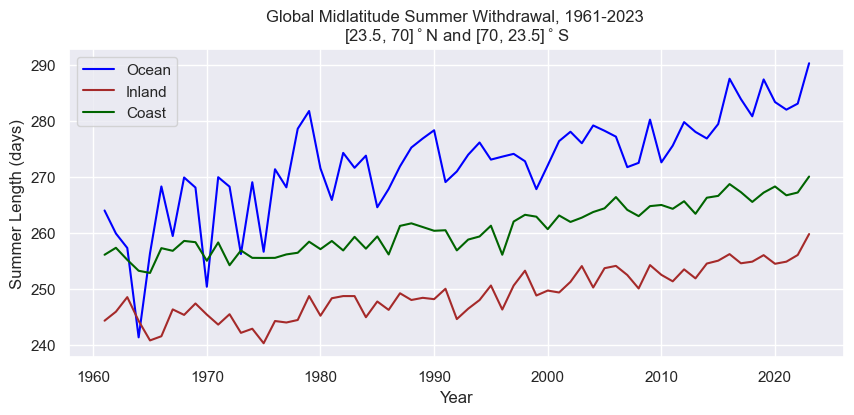

In [235]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_with = ds_land.SummerEnd.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_with = ds_ocean.SummerEnd.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_coast_with = ds_coast.SummerEnd.where(((ds_coast.lat >= 23.5) & (ds_coast.lat <= 70)) | 
                                         ((ds_coast.lat <= -23.5) & (ds_coast.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_with.time.dt.year, wavg_midlat_ocean_with, label="Ocean", color='blue')
plt.plot(wavg_midlat_land_with.time.dt.year, wavg_midlat_land_with, label="Inland", color='brown')
plt.plot(wavg_midlat_coast_with.time.dt.year, wavg_midlat_coast_with, label="Coast", color='darkgreen')
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Withdrawal, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

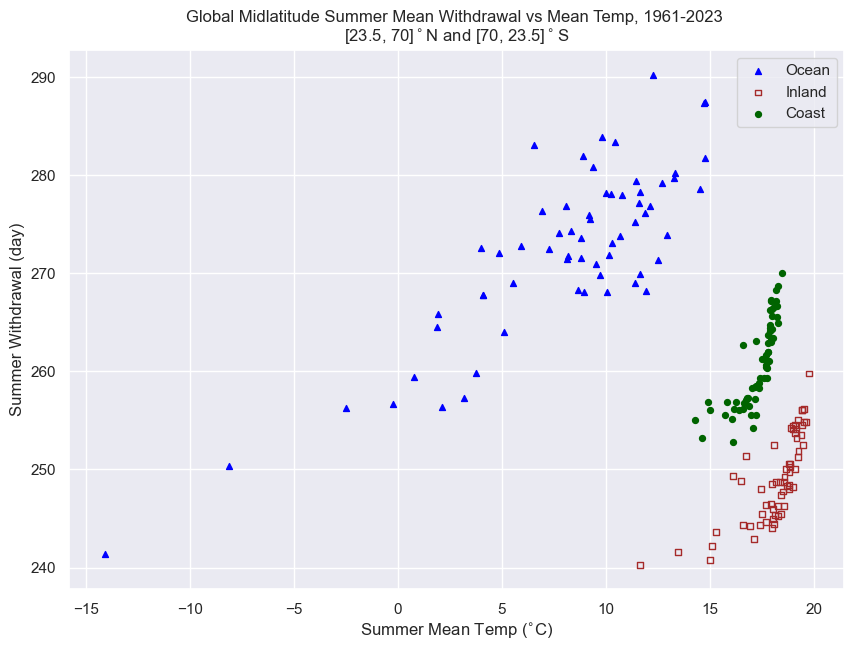

CPU times: user 98.1 ms, sys: 27.9 ms, total: 126 ms
Wall time: 162 ms


In [236]:
%%time

#markers
l_m = 's'
o_m = '^'
c_m = 'o'

plt.figure(figsize=(10,7))
plt.scatter(x=wavg_midlat_ocean_meantemp, y=wavg_midlat_ocean_with, s=s, marker=o_m, label="Ocean", color='blue')
plt.scatter(x=wavg_midlat_land_meantemp, y=wavg_midlat_land_with, marker=l_m, facecolors='none', edgecolors='brown', s=s, label="Inland", color='brown')
plt.scatter(x=wavg_midlat_coast_meantemp, y=wavg_midlat_coast_with, s=s, marker=c_m, label="Coast", color='darkgreen')
plt.xlabel("Summer Mean Temp ($^{\circ}$C)")
plt.ylabel("Summer Withdrawal (day)")
plt.title("Global Midlatitude Summer Mean Withdrawal vs Mean Temp, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()
